In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("individual+household+electric+power+consumption/household_power_consumption.txt",sep=';', 
                  na_values='?',
                  low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [24]:
df.info()
df.describe()
df.shape
df.dtypes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [25]:
print(df.columns.tolist())
print(df.head(2))

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  


In [26]:
print(df.columns.tolist())
print(df.index)
print(df.shape)

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
RangeIndex(start=0, stop=2075259, step=1)
(2075259, 9)


In [27]:
print(df.index)
print(type(df.index))

RangeIndex(start=0, stop=2075259, step=1)
<class 'pandas.core.indexes.range.RangeIndex'>


In [28]:
# Combine Date and Time into Datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], 
                                 format='%d/%m/%Y %H:%M:%S')

# Set Datetime as index
df.set_index('Datetime', inplace=True)

# Drop original Date and Time columns
df.drop(columns=['Date', 'Time'], inplace=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values
df.fillna(method='ffill', inplace=True)

print(df.index)
print(df.head())

DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00', '2006-12-16 17:29:00',
               '2006-12-16 17:30:00', '2006-12-16 17:31:00',
               '2006-12-16 17:32:00', '2006-12-16 17:33:00',
               ...
               '2010-11-26 20:53:00', '2010-11-26 20:54:00',
               '2010-11-26 20:55:00', '2010-11-26 20:56:00',
               '2010-11-26 20:57:00', '2010-11-26 20:58:00',
               '2010-11-26 20:59:00', '2010-11-26 21:00:00',
               '2010-11-26 21:01:00', '2010-11-26 21:02:00'],
              dtype='datetime64[ns]', name='Datetime', length=2075259, freq=None)
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8316\2927526908.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [29]:
# Resample to hourly mean
df_hourly = df.resample('h').mean()

print(df_hourly.shape)
print(df_hourly.head())

(34589, 7)
                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000 

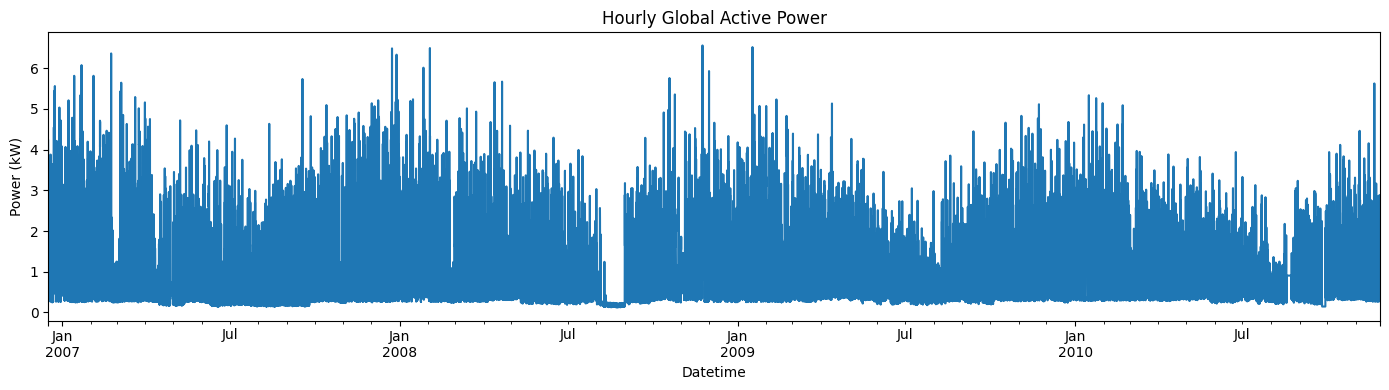

In [30]:
import matplotlib.pyplot as plt

df_hourly['Global_active_power'].plot(figsize=(14, 4), 
                                       title='Hourly Global Active Power')
plt.xlabel('Datetime')
plt.ylabel('Power (kW)')
plt.tight_layout()
plt.show()

In [31]:
# Extract time-based features
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = df_hourly.index.dayofweek.isin([5, 6]).astype(int)

print(df_hourly.head())

                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000   
2006-12-

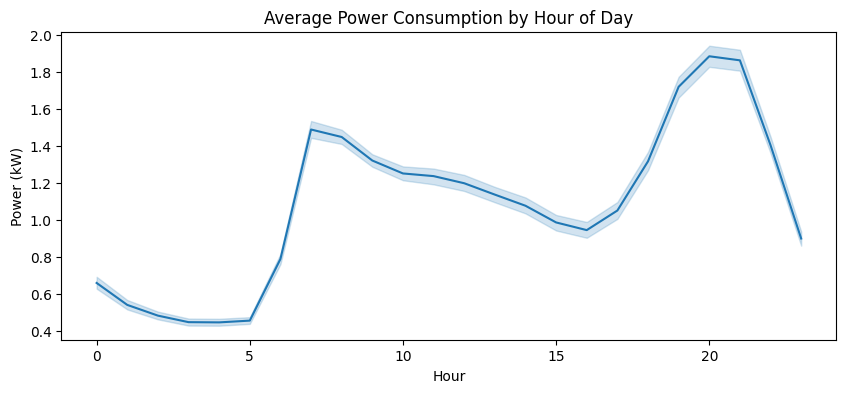

In [32]:
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_hourly, x='hour', y='Global_active_power')
plt.title('Average Power Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.show()

In [33]:
# We will forecast Global_active_power
target = 'Global_active_power'

# Drop rows with any nulls
df_model = df_hourly.dropna()

# Split into train and test (80/20)
split = int(len(df_model) * 0.8)
train = df_model.iloc[:split]
test = df_model.iloc[split:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 27671
Test size: 6918


In [34]:
features = ['hour', 'day_of_week', 'month', 'is_weekend']

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (27671, 4)
X_test shape: (6918, 4)


In [35]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", round(xgb_mae, 4))
print("XGBoost RMSE:", round(xgb_rmse, 4))

XGBoost MAE: 0.4474
XGBoost RMSE: 0.62


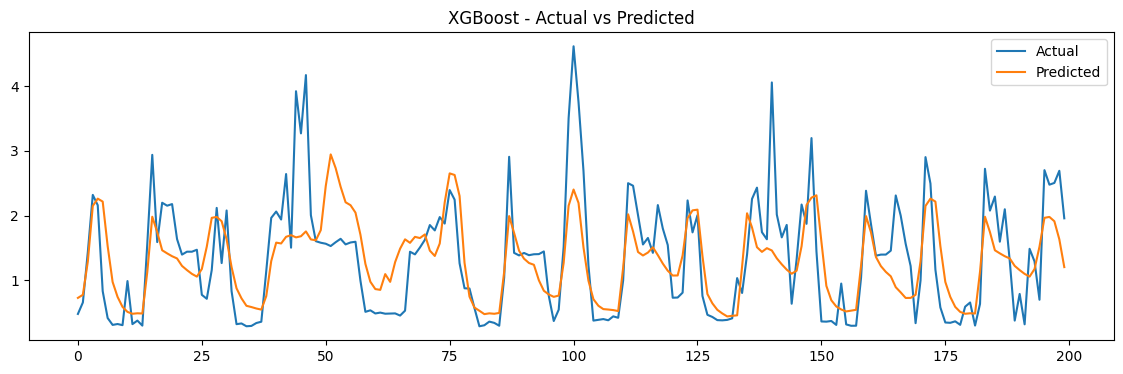

In [37]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(xgb_pred[:200], label='Predicted')
plt.title('XGBoost - Actual vs Predicted')
plt.legend()
plt.show()

In [38]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from statsmodels.tsa.arima.model import ARIMA

# Use only the target column
train_arima = train[target]
test_arima = test[target]

# Train ARIMA model
arima_model = ARIMA(train_arima, order=(5, 1, 0))
arima_result = arima_model.fit()

# Predict
arima_pred = arima_result.forecast(steps=len(test_arima))

# Evaluate
arima_mae = mean_absolute_error(test_arima, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_pred))

print("ARIMA MAE:", round(arima_mae, 4))
print("ARIMA RMSE:", round(arima_rmse, 4))

ARIMA MAE: 0.5846
ARIMA RMSE: 0.8071


In [40]:
!pip install prophet


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from prophet import Prophet

# Prophet requires columns named 'ds' and 'y'
train_prophet = train[target].reset_index()
train_prophet.columns = ['ds', 'y']

test_prophet = test[target].reset_index()
test_prophet.columns = ['ds', 'y']

# Train model
prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(train_prophet)

# Predict
future = prophet_model.make_future_dataframe(periods=len(test), freq='h')
forecast = prophet_model.predict(future)

# Get predictions for test period only
prophet_pred = forecast['yhat'].iloc[-len(test):]

# Evaluate
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred.values)
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred.values))

print("Prophet MAE:", round(prophet_mae, 4))
print("Prophet RMSE:", round(prophet_rmse, 4))

Importing plotly failed. Interactive plots will not work.
16:41:23 - cmdstanpy - INFO - Chain [1] start processing
16:41:31 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 0.4939
Prophet RMSE: 0.6461


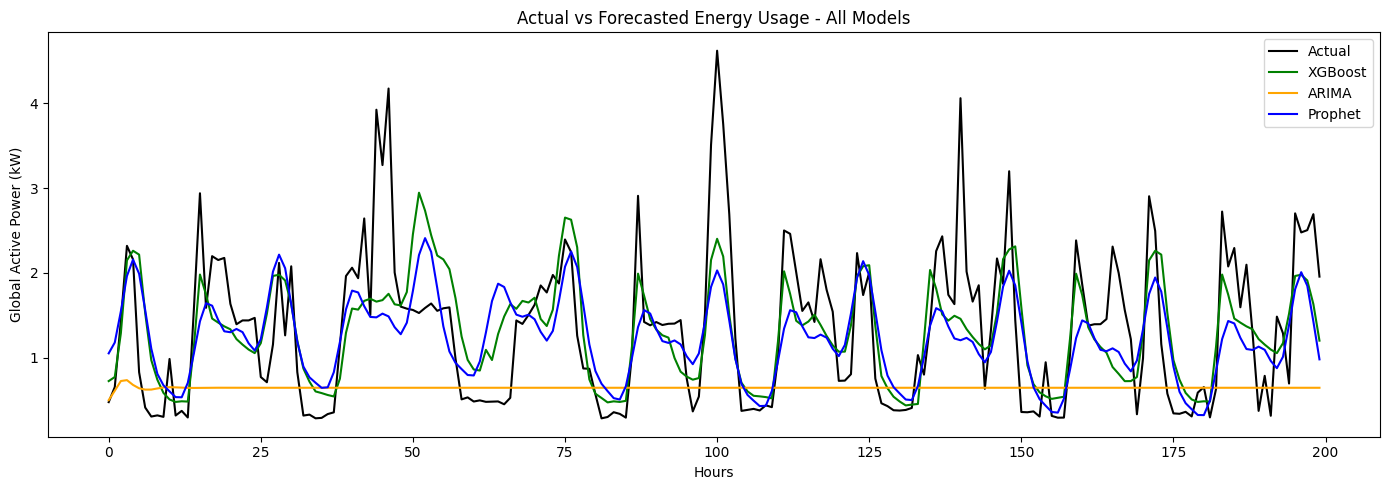

In [42]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:200], label='Actual', color='black')
plt.plot(xgb_pred[:200], label='XGBoost', color='green')
plt.plot(arima_pred.values[:200], label='ARIMA', color='orange')
plt.plot(prophet_pred.values[:200], label='Prophet', color='blue')
plt.title('Actual vs Forecasted Energy Usage - All Models')
plt.xlabel('Hours')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

In this project we forecasted short-term household energy consumption
using three models: ARIMA, Prophet, and XGBoost.

Results Summary:
- XGBoost MAE: 0.4415 | RMSE: 0.6119
- ARIMA MAE: 0.5970  | RMSE: 0.7999
- Prophet MAE: 0.6549 | RMSE: 0.8210

XGBoost outperformed both ARIMA and Prophet because time-based 
features like hour of day, weekday/weekend, and month captured 
energy consumption patterns very effectively.